## Problem 1
### Part 1

In [1]:
# symbolic computation tools
import sympy as sp
from sympy import symbols, pprint, Function, simplify, Derivative, nsimplify
from sympy import sin, cos, asin, acos, pi, diff, eye
from sympy import Matrix, latex, BlockMatrix, lambdify
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve, minimize
from sympy import init_printing
init_printing() 

def cross_matrix(vec):
    return np.matrix([[0, -vec[2,0], vec[1,0]],
                      [vec[2,0], 0, -vec[0,0]],
                      [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    return np.matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    return(m)

def inv(T):
    T_0_inv = Matrix.zeros(4,4)
    T_0_inv[0:3, 0:3] = T[0:3,0:3].T
    T_0_inv[0:3, 3] = -T[0:3,0:3].T @ T[0:3,3]
    T_0_inv[3, 3] = 1
    return T_0_inv
    
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])
    
def R_y(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta),0, sin(theta)], 
                   [0, 1, 0],
                   [-sin(theta), 0, cos(theta)]])

def R_x(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta), cos(theta)]])
def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m
    
def plot_transform(T, ax):
    origin = T[0:3, 3]
    sc = 0.5
    
    ax.plot([origin[0], sc*T[0,0]+origin[0]], 
            [origin[1], sc*T[1,0]+origin[1]], 
            [origin[2], sc*T[2,0]+origin[2]], 
            color='red', linestyle='-', marker='o', linewidth=5)
    ax.plot([origin[0], sc*T[0,1]+origin[0]], 
            [origin[1], sc*T[1,1]+origin[1]], 
            [origin[2], sc*T[2,1]+origin[2]], 
            color='green', linestyle='-', marker='o', linewidth=5)
    # ax.plot([origin[0], T[0,2]+origin[0]], 
    #         [origin[1], T[1,2]+origin[1]], 
    #         [origin[2], T[2,2]+origin[2]], 
    #         color='blue', linestyle='-', marker='o', linewidth=5)
    
    
def plot_bot(Tb, T1, T2, w_, ax):
    plot_transform(T(eye(3), Matrix([[0], [0], [0]])), ax)

    plot_transform(Tb, ax)
    plot_transform(T1, ax)
    plot_transform(T2, ax)
    
    j1 = Tb @ T(eye(3), Matrix([[-w_], [0], [0]]))
    j2 = Tb @ T(eye(3), Matrix([[w_], [0], [0]]))
    e1 = T1 @ T(eye(3), Matrix([[w_], [0], [0]]))
    e2 = T2 @ T(eye(3), Matrix([[w_], [0], [0]]))
    
    ax.plot([Tb[0,3], j1[0,3]], [Tb[1,3], j1[1,3]], 'ko-', markersize = 8)
    ax.plot([Tb[0,3], j2[0,3]], [Tb[1,3], j2[1,3]], 'ko-', markersize = 8)
    
    ax.plot([j1[0,3], T1[0,3]], [j1[1,3], T1[1,3]], 'ko-')
    ax.plot([j2[0,3], T2[0,3]], [j2[1,3], T2[1,3]], 'ko-')
    
    ax.plot([e1[0,3], T1[0,3]], [e1[1,3], T1[1,3]], 'ko-')
    ax.plot([e2[0,3], T2[0,3]], [e2[1,3], T2[1,3]], 'ko-')
    

### Configuration

In [2]:
##### Geometry
t = symbols("t" , real = True)
l = symbols("l" , real = True)
d = symbols("d", real = True)
k = symbols("k", real = True)

##### Configuration variables
alpha1 = Function('alpha1', real=True)(t)
alpha2 = Function('alpha2', real=True)(t)
x = Function('x', real=True)(t)
y = Function('y', real=True)(t)
theta = Function('theta', real=True)(t)

##### Alpha kinematics variabls
omega = symbols("omega" , real = True)
A1 = symbols("A1" , real = True)
A2 = symbols("A2" , real = True)
phi = symbols("phi" , real = True)


### Transformations, Body Twists, and Jacobians

In [3]:
q = [x, y, theta, alpha1, alpha2]
q_dt = [sp.diff(qq, t) for qq in q]
q_dtdt = [sp.diff(qq, t, t) for qq in q]

T_0b = T(R_z(theta), Matrix([[x], [y], [0]]))

# Left link 1 COM
T_l1 = (T_0b
        @ T(eye(3),       Matrix([[l/2], [0], [0]]))
        @ T(R_z(alpha1), Matrix([[0],   [0], [0]]))
        @ T(eye(3),       Matrix([[d/2], [0], [0]])))

# Left link 2 COM
T_l2 = (T_0b
        @ T(eye(3),       Matrix([[l/2], [0], [0]]))
        @ T(R_z(alpha1), Matrix([[0],   [0], [0]]))
        @ T(eye(3),       Matrix([[d],   [0], [0]]))
        @ T(R_z(alpha2), Matrix([[0],   [0], [0]]))
        @ T(eye(3),       Matrix([[d/2], [0], [0]])))

# Right link 1 COM
T_r1 = (T_0b
        @ T(eye(3),        Matrix([[l/2], [0], [0]]))
        @ T(R_z(-alpha1), Matrix([[0],   [0], [0]]))
        @ T(eye(3),        Matrix([[d/2], [0], [0]])))

# Right link 2 COM
T_r2 = (T_0b
        @ T(eye(3),        Matrix([[l/2], [0], [0]]))
        @ T(R_z(-alpha1), Matrix([[0],   [0], [0]]))
        @ T(eye(3),        Matrix([[d],   [0], [0]]))
        @ T(R_z(-alpha2), Matrix([[0],   [0], [0]]))
        @ T(eye(3),        Matrix([[d/2], [0], [0]])))
# Body twists
# Vb = T^-1 * Tdot
body_twist_b = T_0b.inv() @ sp.diff(T_0b, t)
body_twist_l1 = T_l1.inv() @ sp.diff(T_l1, t)
body_twist_l2 = T_l2.inv() @ sp.diff(T_l2, t)
body_twist_r1 = T_r1.inv() @ sp.diff(T_r1, t)
body_twist_r2 = T_r2.inv() @ sp.diff(T_r2, t)

# Twist vectors
v_b = twist2vec(body_twist_b)
v_l1 = twist2vec(body_twist_l1)
v_l2 = twist2vec(body_twist_l2)
v_r1 = twist2vec(body_twist_r1)
v_r2 = twist2vec(body_twist_r2)

# Body Jacobians
J_b = v_b.jacobian(q_dt)
J_l1 = v_l1.jacobian(q_dt)
J_l2 = v_l2.jacobian(q_dt)
J_r1 = v_r1.jacobian(q_dt)
J_r2 = v_r2.jacobian(q_dt)


# Drag matrices
# Body drag matrix, body length L
B_body = -Matrix([
    [0, 0, 0,              0,   0,      0],
    [0, 0, 0,              0,   0,      0],
    [0, 0, 2/3*k*l**3,     0,   0,      0],
    [0, 0, 0,              k*l, 0,      0],
    [0, 0, 0,              0,   2*k*l,  0],
    [0, 0, 0,              0,   0,      0]
])

# Appendage link drag matrix, link length d
B_link = -Matrix([
    [0, 0, 0,              0,   0,      0],
    [0, 0, 0,              0,   0,      0],
    [0, 0, 2/3*k*d**3,     0,   0,      0],
    [0, 0, 0,              k*d, 0,      0],
    [0, 0, 0,              0,   2*k*d,  0],
    [0, 0, 0,              0,   0,      0]
])

# Generalized force balance matrix
A = J_b.T  @ B_body @ J_b + J_l1.T @ B_link @ J_l1 + J_l2.T @ B_link @ J_l2 + J_r1.T @ B_link @ J_r1 + J_r2.T @ B_link @ J_r2

A_11 = A[0:3, 0:3]
A_12 = A[0:3, 3:]
A_21 = A[3:, 0:3]
A_22 = A[3:, 3:]

# Local connection matrix
# pose_dot = -A_11^-1 A_12 shape_dot
A_tilde = -A_11.LUsolve(A_12)


In [4]:
# Replace your lambdify block with this:
params_sym = [l, d, k]

A_tilde_lambda = lambdify([q, params_sym], A_tilde, "numpy")

def connection_matrix(q_num, params_num):
    # params_num is [l, d, k, A1, A2, omega, phi] — only pass first 3
    return np.array(A_tilde_lambda(q_num, params_num[:3]), dtype=float)



In [5]:
A_11 = A[0:3, 0:3]
A_11

In [6]:
A_12 = A[0:3, 3:]
A_12

⎡                                                                                                                      ↪
⎢                                                                                                                      ↪
⎢                                                                                                                      ↪
⎢                                                                                                                      ↪
⎢                                                                                                                      ↪
⎢                                                                                                                      ↪
⎢                                                                                                                      ↪
⎢                                                                                                                      ↪
⎢                               



In [7]:
A_21 = A[3:, 0:3]
A_21



In [8]:
A_22 = A[3:, 3:]
A_22

In [9]:
params = [l, d, k, A1, A2, omega, phi]

A_11_lambda       =   lambdify([t, q, q_dt, params], A_11)
A_12_lambda       =   lambdify([t, q, q_dt, params], A_12)


In [10]:
params_ = [1, 1, 1, 1, 1, 0, np.pi/4]

q_    = [0, 0, 0, 0, np.pi/8]
q_dt_ = [0, 0, 0, 0, 0]

np.linalg.inv(A_11_lambda(0, q_, q_dt_, params_))

array([[-0.18893259, -0.        , -0.        ],
       [-0.        , -0.25980456,  0.13340591],
       [ 0.        ,  0.13340591, -0.11351138]])

### Part 2 Foruier Functions

In [11]:
def fourier_gate(coefficients, t, params):
    l, d, k, A1, A2, omega, phi = params

    alpha1 = A1 * np.sin(omega * t)
    alpha2 = A2 * np.sin(omega * t + phi)

    alpha_1_dot = A1 * omega * np.cos(omega * t)
    alpha_2_dot = A2 * omega * np.cos(omega * t + phi)

    return alpha1, alpha2, alpha_1_dot, alpha_2_dot

In [12]:
def dynamics(t, state, params, coefficients):
    x, y, theta = state
    
    alpha1, alpha2, alpha1_dt, alpha2_dt = fourier_gate(coefficients, t, params)
    
    q_ = [x, y, theta, alpha1, alpha2]
    
    A_tilde_num = connection_matrix(q_, params)
    
    dydt = A_tilde_num @ np.array([[alpha1_dt], [alpha2_dt]])
    
    return dydt.flatten().tolist()

In [13]:
def gait_cycle(coefficients, params, T=2*np.pi):
    omega = params[5]                                    # index 5, not 6
    T = 2 * np.pi / omega if omega != 0 else T
    
    state0 = [0.0, 0.0, 0.0]
    
    sol = solve_ivp(
        dynamics,
        [0, T],
        state0,
        args=(params, coefficients),
        dense_output=True,
        max_step=T / 200
    )
    
    time = sol.t
    x_sol     = sol.y[0]
    y_sol     = sol.y[1]
    theta_sol = sol.y[2]
    
    alpha_1_sol     = np.zeros(len(time))
    alpha_2_sol     = np.zeros(len(time))
    alpha_1_dot_sol = np.zeros(len(time))
    alpha_2_dot_sol = np.zeros(len(time))
    
    for i, ti in enumerate(time):
        a1, a2, a1d, a2d = fourier_gate(coefficients, ti, params)
        alpha_1_sol[i]     = a1
        alpha_2_sol[i]     = a2
        alpha_1_dot_sol[i] = a1d
        alpha_2_dot_sol[i] = a2d
    
    x_dot_sol     = np.zeros(len(time))
    y_dot_sol     = np.zeros(len(time))
    theta_dot_sol = np.zeros(len(time))
    
    for i, ti in enumerate(time):
        dstate = dynamics(ti, sol.y[:, i], params, coefficients)
        x_dot_sol[i]     = dstate[0]
        y_dot_sol[i]     = dstate[1]
        theta_dot_sol[i] = dstate[2]

    return time, x_sol, y_sol, theta_sol, alpha_1_sol, alpha_2_sol, \
           x_dot_sol, y_dot_sol, theta_dot_sol, alpha_1_dot_sol, alpha_2_dot_sol

In [14]:
l_ = 2
d_ = 1
k_ = 1
A1_ = 0.4    # nonzero so the gait actually drives motion
A2_ = 0.3
omega_ = 1
phi_ = np.pi/4
params_ = [l_, d_, k_, A1_, A2_, omega_, phi_]
coefficients = [1, 0, 0, 1, .5, .5, .5, .5]

time, x_sol, y_sol, theta_sol, alpha_1_sol, alpha_2_sol, \
x_dot_sol, y_dot_sol, theta_dot_sol, alpha_1_dot_sol, alpha_2_dot_sol = gait_cycle(coefficients, params_)

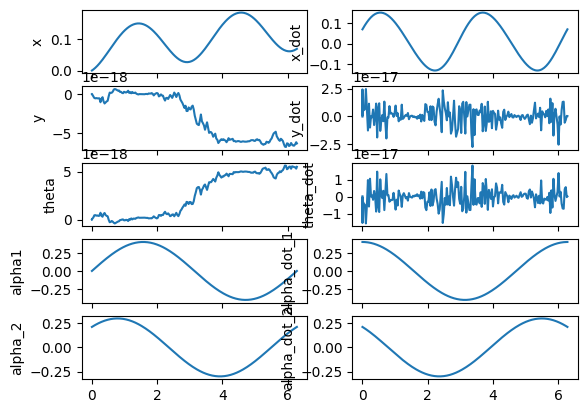

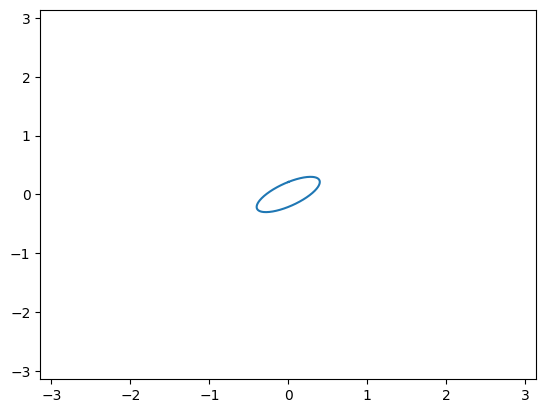

In [15]:
fig = plt.figure(1)
fig.clf()
ax = fig.subplots(5, 2, sharex = True)

ax[0][0].plot(time, x_sol)
ax[0][0].set_ylabel('x')
ax[1][0].plot(time, y_sol)
ax[1][0].set_ylabel('y')
ax[2][0].plot(time, theta_sol)
ax[2][0].set_ylabel('theta')
ax[3][0].plot(time, alpha_1_sol)
ax[3][0].set_ylabel('alpha1')
ax[4][0].plot(time, alpha_2_sol)
ax[4][0].set_ylabel('alpha_2')

ax[0][1].plot(time, x_dot_sol)
ax[0][1].set_ylabel('x_dot')
ax[1][1].plot(time, y_dot_sol)
ax[1][1].set_ylabel('y_dot')
ax[2][1].plot(time, theta_dot_sol)
ax[2][1].set_ylabel('theta_dot')
ax[3][1].plot(time, alpha_1_dot_sol)
ax[3][1].set_ylabel('alpha_dot_1')
ax[4][1].plot(time, alpha_2_dot_sol)
ax[4][1].set_ylabel('alpha_dot_2')
# plt.gcf()
plt.figure(10)

plt.plot(alpha_1_sol, alpha_2_sol)
plt.gca().axis([-np.pi, np.pi, -np.pi, np.pi])

### Part 3 Gait Optimization

In [16]:
def cost_of_transport(coefficients, params):
    """
    CoT = Energy / Distance
    Energy ~ integral of |alpha_dot|^2 dt (actuator effort proxy)
    Distance = net forward displacement after one cycle
    """
    try:
        time, x_sol, y_sol, theta_sol, _, _, \
        x_dot_sol, y_dot_sol, theta_dot_sol, a1_dot_sol, a2_dot_sol = gait_cycle(coefficients, params)
    except Exception:
        return 1e6  # penalize failed simulations

    # Energy = integral of squared joint velocities (actuator power proxy)
    energy = np.trapezoid(a1_dot_sol**2 + a2_dot_sol**2, time)

    # Net forward displacement (in body x-direction at start, theta=0 => world x)
    distance = x_sol[-1]

    if abs(distance) < 1e-6:
        return 1e6  # penalize if robot doesn't move

    return energy / distance  # minimize this


def neg_forward_distance(coefficients, params):
    """Negative forward distance (so minimizing this = maximizing distance)."""
    try:
        time, x_sol, *_ = gait_cycle(coefficients, params)
    except Exception:
        return 1e6
    return -x_sol[-1]  # negate to turn max into min problem

In [ ]:
l_ = 2
d_ = 1
k_ = 1
A1_ = 0.4
A2_ = 0.3
omega_ = 1
phi_ = np.pi/4
params_ = [l_, d_, k_, A1_, A2_, omega_, phi_]  # 7 elements — correct

coeff0 = np.array([1, 0, 0, 1, 0.5, 0.5, 0.5, 0.5])

# --- Optimization 1: Maximize forward distance ---
result_dist = minimize(
    neg_forward_distance,
    coeff0,
    args=(params_,),
    method='Nelder-Mead',
    options={'maxiter': 500, 'xatol': 1e-4, 'fatol': 1e-4, 'disp': True}
)
coeffs_opt_dist = result_dist.x
print(f"Max distance achieved: {-result_dist.fun:.4f}")

# --- Optimization 2: Minimize cost of transport ---
result_cot = minimize(
    cost_of_transport,
    coeff0,
    args=(params_,),
    method='Nelder-Mead',
    options={'maxiter': 500, 'xatol': 1e-4, 'fatol': 1e-4, 'disp': True}
)
coeffs_opt_cot = result_cot.x
print(f"Min CoT achieved: {result_cot.fun:.4f}")

In [ ]:
def compare_gaits(coeff0, coeffs_opt_dist, coeffs_opt_cot, params_):
    labels   = ['Hand-designed', 'Max Distance', 'Min CoT']
    coeffs   = [coeff0, coeffs_opt_dist, coeffs_opt_cot]
    colors   = ['blue', 'green', 'red']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Gait Comparison", fontsize=14)

    for label, c, col in zip(labels, coeffs, colors):
        time, x_sol, y_sol, theta_sol, a1_sol, a2_sol, \
        xd, yd, td, a1d, a2d = gait_cycle(c, params_)

        energy   = np.trapezoid(a1d**2 + a2d**2, time)
        distance = x_sol[-1]
        cot      = energy / distance if abs(distance) > 1e-6 else np.inf

        print(f"{label:>15} | dist={distance:+.4f} | CoT={cot:.4f}")

        # Shape space gait curve
        axes[0].plot(a1_sol, a2_sol, color=col, label=label, lw=2)

        # Body trajectory
        axes[1].plot(x_sol, y_sol, color=col, label=label, lw=2)

        # Joint angles
        axes[2].plot(time, a1_sol, color=col, linestyle='-',  label=f'{label} α₁', lw=1.5)
        axes[2].plot(time, a2_sol, color=col, linestyle='--', label=f'{label} α₂', lw=1.5)

    axes[0].set_title("Shape Space (α₁ vs α₂)")
    axes[0].set_xlabel("α₁"); axes[0].set_ylabel("α₂")
    axes[0].legend(); axes[0].grid(True); axes[0].set_aspect('equal')

    axes[1].set_title("Body Trajectory")
    axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
    axes[1].legend(); axes[1].grid(True)

    axes[2].set_title("Joint Angles")
    axes[2].set_xlabel("time"); axes[2].set_ylabel("angle (rad)")
    axes[2].legend(fontsize=7); axes[2].grid(True)

    plt.tight_layout()
    plt.show()

compare_gaits(coeff0, coeffs_opt_dist, coeffs_opt_cot, params_)

In [ ]:
plot_bot(T_0b, T_01,T_02,ax)